# ARC Prize 2026 - Hybrid Solver (Beam Search + Island-Model GA)

This notebook is a self-contained, singleton solution designed for the Kaggle environment. 
It breaks down the solver architecture into distinct, readable code cells and concludes with an **Exploratory Data Analysis (EDA)** section that runs the solver on sample data and visually plots the predictions.

### Architecture Overview
1. **Core Solver Components**: Grid representation, Object extraction, and Primitive transformations (75+ operations).
2. **Heuristic Solvers**: Fast deterministic algorithms for common ARC patterns.
3. **Genetic Algorithm**: Island-model GA with diff-based seeding and schema-preserving crossover for complex tasks.
4. **Hybrid Orchestrator**: Combines Beam Search and GA into a unified prediction pipeline.
5. **Exploratory Analysis & Visualization**: Output-centric testing on evaluation datasets.


In [1]:
import numpy as np
import collections
import random
import time
import json
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


## Core Solver Components

In [2]:
"""
ARC Prize 2026 — Core Solver Module
====================================
DSA-based heuristic solver using:
  - BFS/DFS connected components for object extraction
  - Node-based block analysis (graph of objects)
  - Mathematical symmetry / periodicity detection
  - Beam search over candidate transformation rules
"""

import numpy as np
import collections
import copy
from itertools import product

### Section 1 — Grid Representation

In [3]:
class Grid:
    """Immutable 2D grid of colors [0..9]."""

    def __init__(self, data):
        if isinstance(data, np.ndarray):
            self.data = data.astype(int)
        else:
            self.data = np.array(data, dtype=int)

    @property
    def height(self):
        return self.data.shape[0]

    @property
    def width(self):
        return self.data.shape[1]

    @property
    def shape(self):
        return (self.height, self.width)

    def __eq__(self, other):
        if not isinstance(other, Grid):
            return False
        return np.array_equal(self.data, other.data)

    def __hash__(self):
        return hash(self.data.tobytes())

    def __repr__(self):
        return f"Grid({self.height}x{self.width})"

    def to_list(self):
        return self.data.tolist()

    def copy(self):
        return Grid(self.data.copy())

    def unique_colors(self):
        return set(np.unique(self.data).tolist())

    def color_counts(self):
        colors, counts = np.unique(self.data, return_counts=True)
        return dict(zip(colors.tolist(), counts.tolist()))

    def background_color(self):
        """Most frequent color = background (heuristic)."""
        cc = self.color_counts()
        return max(cc, key=cc.get)

    def cell(self, r, c):
        return int(self.data[r, c])

### Section 2 — Object Extraction (BFS Connected Components)

In [4]:
class ArcObject:
    """Represents a connected component (block/node) in the grid."""

    def __init__(self, coords, grid):
        """
        coords: list of (row, col) tuples
        grid: the parent Grid
        """
        self.coords = coords
        self.color_map = {}  # (r, c) -> color
        for r, c in coords:
            self.color_map[(r, c)] = grid.cell(r, c)

        rows = [r for r, c in coords]
        cols = [c for r, c in coords]
        self.min_r, self.max_r = min(rows), max(rows)
        self.min_c, self.max_c = min(cols), max(cols)

    @property
    def bbox(self):
        return (self.min_r, self.min_c, self.max_r, self.max_c)

    @property
    def bbox_height(self):
        return self.max_r - self.min_r + 1

    @property
    def bbox_width(self):
        return self.max_c - self.min_c + 1

    @property
    def area(self):
        return len(self.coords)

    @property
    def colors(self):
        return set(self.color_map.values())

    @property
    def primary_color(self):
        """Most frequent color in this object."""
        cc = collections.Counter(self.color_map.values())
        return cc.most_common(1)[0][0]

    @property
    def centroid(self):
        rows = [r for r, c in self.coords]
        cols = [c for r, c in self.coords]
        return (sum(rows) / len(rows), sum(cols) / len(cols))

    def subgrid(self, bg=0):
        """Extract this object as a standalone grid with background fill."""
        h, w = self.bbox_height, self.bbox_width
        sub = np.full((h, w), bg, dtype=int)
        for (r, c), color in self.color_map.items():
            sub[r - self.min_r, c - self.min_c] = color
        return Grid(sub)

    def normalized_shape(self, bg=0):
        """Binary mask of the object shape (for shape comparison)."""
        h, w = self.bbox_height, self.bbox_width
        mask = np.zeros((h, w), dtype=int)
        for r, c in self.coords:
            mask[r - self.min_r, c - self.min_c] = 1
        return mask


def find_objects(grid, bg=0, connectivity=4):
    """
    BFS-based connected component extraction.
    Groups all non-background cells into objects.
    connectivity: 4 (cardinal) or 8 (cardinal + diagonal)
    Returns list of ArcObject.
    """
    h, w = grid.height, grid.width
    visited = np.zeros((h, w), dtype=bool)
    objects = []

    if connectivity == 4:
        deltas = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    else:
        deltas = [(dr, dc) for dr in [-1, 0, 1] for dc in [-1, 0, 1] if (dr, dc) != (0, 0)]

    for r in range(h):
        for c in range(w):
            if grid.cell(r, c) != bg and not visited[r, c]:
                # BFS flood
                queue = collections.deque([(r, c)])
                visited[r, c] = True
                component = []
                while queue:
                    cr, cc = queue.popleft()
                    component.append((cr, cc))
                    for dr, dc in deltas:
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < h and 0 <= nc < w and not visited[nr, nc] and grid.cell(nr, nc) != bg:
                            visited[nr, nc] = True
                            queue.append((nr, nc))
                objects.append(ArcObject(component, grid))

    return objects


def find_objects_by_color(grid, color):
    """Extract connected components of a single specific color."""
    h, w = grid.height, grid.width
    visited = np.zeros((h, w), dtype=bool)
    objects = []
    deltas = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    for r in range(h):
        for c in range(w):
            if grid.cell(r, c) == color and not visited[r, c]:
                queue = collections.deque([(r, c)])
                visited[r, c] = True
                component = []
                while queue:
                    cr, cc = queue.popleft()
                    component.append((cr, cc))
                    for dr, dc in deltas:
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < h and 0 <= nc < w and not visited[nr, nc] and grid.cell(nr, nc) == color:
                            visited[nr, nc] = True
                            queue.append((nr, nc))
                objects.append(ArcObject(component, grid))
    return objects

### Section 3 — Grid Transformations

In [5]:
def rotate90(grid):
    """Rotate grid 90° clockwise."""
    return Grid(np.rot90(grid.data, k=-1))

def rotate180(grid):
    return Grid(np.rot90(grid.data, k=2))

def rotate270(grid):
    return Grid(np.rot90(grid.data, k=1))

def mirror_horizontal(grid):
    """Flip left-right."""
    return Grid(np.fliplr(grid.data))

def mirror_vertical(grid):
    """Flip top-bottom."""
    return Grid(np.flipud(grid.data))

def transpose(grid):
    return Grid(grid.data.T)

def crop_to_content(grid, bg=0):
    """Crop to bounding box of all non-background cells."""
    rows = np.any(grid.data != bg, axis=1)
    cols = np.any(grid.data != bg, axis=0)
    if not np.any(rows) or not np.any(cols):
        return Grid(np.array([[bg]]))
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return Grid(grid.data[rmin:rmax + 1, cmin:cmax + 1])

def scale_up(grid, factor):
    """Scale grid by integer factor (nearest-neighbor)."""
    return Grid(np.repeat(np.repeat(grid.data, factor, axis=0), factor, axis=1))

def tile_grid(grid, repeat_r, repeat_c):
    """Tile/repeat a grid pattern."""
    return Grid(np.tile(grid.data, (repeat_r, repeat_c)))

def color_swap(grid, old_color, new_color):
    """Replace all cells of old_color with new_color."""
    new_data = grid.data.copy()
    new_data[new_data == old_color] = new_color
    return Grid(new_data)

def color_map(grid, mapping):
    """Apply a color mapping dictionary {old: new}."""
    new_data = grid.data.copy()
    for old, new in mapping.items():
        new_data[grid.data == old] = new
    return Grid(new_data)

def flood_fill(grid, start_r, start_c, new_color):
    """BFS flood fill from a starting cell."""
    new_data = grid.data.copy()
    old_color = int(new_data[start_r, start_c])
    if old_color == new_color:
        return Grid(new_data)
    h, w = grid.height, grid.width
    queue = collections.deque([(start_r, start_c)])
    new_data[start_r, start_c] = new_color
    while queue:
        r, c = queue.popleft()
        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and int(new_data[nr, nc]) == old_color:
                new_data[nr, nc] = new_color
                queue.append((nr, nc))
    return Grid(new_data)

def overlay(base, overlay_grid, offset_r=0, offset_c=0, transparent=0):
    """Place overlay_grid on top of base at offset, treating transparent color as see-through."""
    result = base.data.copy()
    for r in range(overlay_grid.height):
        for c in range(overlay_grid.width):
            tr, tc = r + offset_r, c + offset_c
            if 0 <= tr < base.height and 0 <= tc < base.width:
                val = overlay_grid.cell(r, c)
                if val != transparent:
                    result[tr, tc] = val
    return Grid(result)

def gravity_down(grid, bg=0):
    """Drop all non-background cells downward (column-wise gravity)."""
    new_data = grid.data.copy()
    for c in range(grid.width):
        col = new_data[:, c]
        non_bg = col[col != bg]
        new_col = np.full(grid.height, bg, dtype=int)
        new_col[grid.height - len(non_bg):] = non_bg
        new_data[:, c] = new_col
    return Grid(new_data)

def extract_subgrid(grid, r1, c1, r2, c2):
    """Extract a rectangular subgrid [r1:r2+1, c1:c2+1]."""
    return Grid(grid.data[r1:r2 + 1, c1:c2 + 1])

def pad_grid(grid, top=0, bottom=0, left=0, right=0, fill=0):
    """Pad grid with a fill color."""
    return Grid(np.pad(grid.data, ((top, bottom), (left, right)),
                       mode='constant', constant_values=fill))

### Section 3b — Primitive Registry (for Genetic Algorithm)

In [6]:
def _fill_enclosed_default(grid, fill_color=1):
    """Fill all enclosed background regions with fill_color."""
    h, w = grid.height, grid.width
    bg = grid.background_color()
    result = grid.data.copy()

    reachable = np.zeros((h, w), dtype=bool)
    queue = collections.deque()
    for r in range(h):
        for c in [0, w - 1]:
            if int(result[r, c]) == bg and not reachable[r, c]:
                reachable[r, c] = True
                queue.append((r, c))
    for c in range(w):
        for r in [0, h - 1]:
            if int(result[r, c]) == bg and not reachable[r, c]:
                reachable[r, c] = True
                queue.append((r, c))

    while queue:
        cr, cc = queue.popleft()
        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            nr, nc = cr + dr, cc + dc
            if 0 <= nr < h and 0 <= nc < w and not reachable[nr, nc] and int(result[nr, nc]) == bg:
                reachable[nr, nc] = True
                queue.append((nr, nc))

    for r in range(h):
        for c in range(w):
            if int(result[r, c]) == bg and not reachable[r, c]:
                result[r, c] = fill_color
    return Grid(result)


def _enforce_sym_h(grid):
    """Enforce horizontal symmetry (left→right)."""
    data = grid.data.copy()
    h, w = data.shape
    for r in range(h):
        for c in range(w // 2):
            data[r, w - 1 - c] = data[r, c]
    return Grid(data)


def _enforce_sym_v(grid):
    """Enforce vertical symmetry (top→bottom)."""
    data = grid.data.copy()
    h, w = data.shape
    for r in range(h // 2):
        data[h - 1 - r, :] = data[r, :]
    return Grid(data)


def _gravity_up(grid, bg=0):
    """Gravity upward."""
    return mirror_vertical(gravity_down(mirror_vertical(grid), bg=bg))


def _gravity_right(grid, bg=0):
    """Gravity rightward."""
    return rotate270(gravity_down(rotate90(grid), bg=bg))


def _gravity_left(grid, bg=0):
    """Gravity leftward."""
    return rotate90(gravity_down(rotate270(grid), bg=bg))


def _extract_largest_object(grid, bg=0):
    """Extract the largest connected component as a subgrid."""
    objs = find_objects(grid, bg=bg)
    if not objs:
        return grid
    largest = max(objs, key=lambda o: o.area)
    return largest.subgrid(bg=bg)


def _extract_smallest_object(grid, bg=0):
    """Extract the smallest connected component as a subgrid."""
    objs = find_objects(grid, bg=bg)
    if not objs:
        return grid
    smallest = min(objs, key=lambda o: o.area)
    return smallest.subgrid(bg=bg)


def _remove_border(grid):
    """Remove 1-cell border."""
    if grid.height < 3 or grid.width < 3:
        return grid
    return extract_subgrid(grid, 1, 1, grid.height - 2, grid.width - 2)


def _identity(grid):
    """Identity transform."""
    return grid

### Section 3c — Extended Primitives (Color, Boolean, Structural)

In [7]:
def _keep_color(grid, color):
    """Zero out all cells except those matching 'color'; keep background."""
    bg = grid.background_color()
    data = grid.data.copy()
    result = np.full_like(data, bg)
    result[data == color] = color
    return Grid(result)


def _fill_all_with_color(grid, color):
    """Replace every non-background cell with 'color'."""
    bg = grid.background_color()
    data = grid.data.copy()
    data[data != bg] = color
    return Grid(data)


def _remove_color(grid, color):
    """Replace every cell of 'color' with the background color."""
    bg = grid.background_color()
    data = grid.data.copy()
    data[data == color] = bg
    return Grid(data)


def _color_invert(grid):
    """Swap background color with the most frequent foreground color."""
    bg = grid.background_color()
    cc = grid.color_counts()
    non_bg = {k: v for k, v in cc.items() if k != bg}
    if not non_bg:
        return grid
    fg = max(non_bg, key=non_bg.get)
    data = grid.data.copy()
    result = data.copy()
    result[data == bg] = fg
    result[data == fg] = bg
    return Grid(result)


def _remap_by_frequency(grid):
    """Remap colors so most-frequent non-bg → 1, second → 2, etc."""
    bg = grid.background_color()
    cc = grid.color_counts()
    non_bg = {k: v for k, v in cc.items() if k != bg}
    if not non_bg:
        return grid
    sorted_colors = sorted(non_bg.keys(), key=lambda c: non_bg[c], reverse=True)
    mapping = {c: (i + 1) for i, c in enumerate(sorted_colors)}
    mapping[bg] = bg
    data = grid.data.copy()
    result = np.full_like(data, bg)
    for old_c, new_c in mapping.items():
        result[data == old_c] = new_c
    return Grid(result)


def _outline_objects(grid):
    """Keep only border cells of each object (hollow interiors)."""
    bg = grid.background_color()
    data = grid.data
    h, w = data.shape
    result = np.full_like(data, bg)
    for r in range(h):
        for c in range(w):
            if int(data[r, c]) != bg:
                for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                    nr, nc = r + dr, c + dc
                    if not (0 <= nr < h and 0 <= nc < w) or int(data[nr, nc]) == bg:
                        result[r, c] = data[r, c]
                        break
    return Grid(result)


def _mirror_diag(grid):
    """Transpose (mirror along main diagonal) — only for square grids."""
    if grid.height == grid.width:
        return Grid(grid.data.T)
    return grid


def _mirror_anti_diag(grid):
    """Mirror along anti-diagonal — only for square grids."""
    if grid.height == grid.width:
        return Grid(np.rot90(np.fliplr(grid.data)))
    return grid


def _downscale_2x(grid):
    """Take every 2nd row and column (nearest-neighbor downscale by 2)."""
    return Grid(grid.data[::2, ::2])


def _downscale_3x(grid):
    """Take every 3rd row and column (nearest-neighbor downscale by 3)."""
    return Grid(grid.data[::3, ::3])


def _sort_rows_by_sum(grid):
    """Sort rows in ascending order of their color-value sum."""
    rows = list(grid.data)
    rows.sort(key=lambda r: int(np.sum(r)))
    return Grid(np.array(rows))


def _sort_cols_by_sum(grid):
    """Sort columns in ascending order of their color-value sum."""
    cols = list(grid.data.T)
    cols.sort(key=lambda c: int(np.sum(c)))
    return Grid(np.array(cols).T)


# Boolean halves — horizontal split
def _halves_h_or(grid):
    """Top half OR bottom half → non-bg from either half."""
    if grid.height % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.height // 2
    t, b = grid.data[:m, :], grid.data[m:, :]
    result = np.where(t != bg, t, b)
    return Grid(result)


def _halves_h_and(grid):
    """Top half AND bottom half → non-bg only when both halves non-bg."""
    if grid.height % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.height // 2
    t, b = grid.data[:m, :], grid.data[m:, :]
    result = np.where((t != bg) & (b != bg), t, np.full_like(t, bg))
    return Grid(result)


def _halves_h_xor(grid):
    """Top half XOR bottom half → non-bg in exactly one half."""
    if grid.height % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.height // 2
    t, b = grid.data[:m, :], grid.data[m:, :]
    result = np.full_like(t, bg)
    result[(t != bg) & (b == bg)] = t[(t != bg) & (b == bg)]
    result[(t == bg) & (b != bg)] = b[(t == bg) & (b != bg)]
    return Grid(result)


# Boolean halves — vertical split
def _halves_v_or(grid):
    """Left half OR right half → non-bg from either half."""
    if grid.width % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.width // 2
    l, r = grid.data[:, :m], grid.data[:, m:]
    return Grid(np.where(l != bg, l, r))


def _halves_v_and(grid):
    """Left half AND right half → non-bg only when both halves non-bg."""
    if grid.width % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.width // 2
    l, r = grid.data[:, :m], grid.data[:, m:]
    return Grid(np.where((l != bg) & (r != bg), l, np.full_like(l, bg)))


def _halves_v_xor(grid):
    """Left half XOR right half → non-bg in exactly one half."""
    if grid.width % 2 != 0:
        return grid
    bg = grid.background_color()
    m = grid.width // 2
    l, r = grid.data[:, :m], grid.data[:, m:]
    result = np.full_like(l, bg)
    result[(l != bg) & (r == bg)] = l[(l != bg) & (r == bg)]
    result[(l == bg) & (r != bg)] = r[(l == bg) & (r != bg)]
    return Grid(result)


def _count_to_color(grid):
    """Return a 1×1 grid whose value is the number of distinct non-bg objects."""
    bg = grid.background_color()
    objs = find_objects(grid, bg=bg)
    count = min(len(objs), 9)  # Clamp to valid color range
    return Grid(np.array([[count]]))


def _unique_rows(grid):
    """Deduplicate rows, keeping first occurrence of each unique row."""
    seen = []
    result = []
    for row in grid.data:
        key = tuple(row.tolist())
        if key not in seen:
            seen.append(key)
            result.append(row)
    if not result:
        return grid
    return Grid(np.array(result))


def _repeat_border(grid):
    """Pad grid by repeating its border pixels once."""
    data = grid.data
    top = data[0:1, :]
    bot = data[-1:, :]
    mid = np.hstack([data[:, 0:1], data, data[:, -1:]])
    full = np.vstack([np.hstack([data[0:1, 0:1], top, data[0:1, -1:]]),
                      mid,
                      np.hstack([data[-1:, 0:1], bot, data[-1:, -1:]])])
    return Grid(full)


def _fill_bg_with_most_common_fg(grid):
    """Replace background with the single most-common foreground color."""
    bg = grid.background_color()
    cc = grid.color_counts()
    non_bg = {k: v for k, v in cc.items() if k != bg}
    if not non_bg:
        return grid
    fg = max(non_bg, key=non_bg.get)
    data = grid.data.copy()
    data[data == bg] = fg
    return Grid(data)



# The master registry: name → callable(Grid) → Grid
PRIMITIVE_REGISTRY = {
    # ── Identity ────────────────────────────────────────────────────
    "identity": _identity,

    # ── Geometric (rigid transforms) ────────────────────────────────
    "rotate90":            rotate90,
    "rotate180":           rotate180,
    "rotate270":           rotate270,
    "mirror_h":            mirror_horizontal,
    "mirror_v":            mirror_vertical,
    "transpose":           transpose,
    "mirror_diag":         _mirror_diag,
    "mirror_anti_diag":    _mirror_anti_diag,

    # ── Symmetry enforcement ────────────────────────────────────────
    "enforce_sym_h":       _enforce_sym_h,
    "enforce_sym_v":       _enforce_sym_v,

    # ── Crop / extract ──────────────────────────────────────────────
    "crop":                lambda g: crop_to_content(g, bg=0),
    "crop_bg1":            lambda g: crop_to_content(g, bg=1),
    "extract_largest":     _extract_largest_object,
    "extract_smallest":    _extract_smallest_object,
    "unique_rows":         _unique_rows,

    # ── Scaling ─────────────────────────────────────────────────────
    "scale_2x":            lambda g: scale_up(g, 2),
    "scale_3x":            lambda g: scale_up(g, 3),
    "downscale_2x":        _downscale_2x,
    "downscale_3x":        _downscale_3x,

    # ── Tiling ──────────────────────────────────────────────────────
    "tile_2x2":            lambda g: tile_grid(g, 2, 2),
    "tile_1x2":            lambda g: tile_grid(g, 1, 2),
    "tile_2x1":            lambda g: tile_grid(g, 2, 1),
    "tile_3x3":            lambda g: tile_grid(g, 3, 3),
    "tile_1x3":            lambda g: tile_grid(g, 1, 3),
    "tile_3x1":            lambda g: tile_grid(g, 3, 1),

    # ── Gravity ─────────────────────────────────────────────────────
    "gravity_down":        lambda g: gravity_down(g, bg=0),
    "gravity_up":          _gravity_up,
    "gravity_right":       _gravity_right,
    "gravity_left":        _gravity_left,

    # ── Fill operations ─────────────────────────────────────────────
    "fill_enclosed":       _fill_enclosed_default,
    "outline_objects":     _outline_objects,
    "fill_bg_with_fg":     _fill_bg_with_most_common_fg,

    # ── Border operations ───────────────────────────────────────────
    "remove_border":       _remove_border,
    "add_border_0":        lambda g: pad_grid(g, 1, 1, 1, 1, fill=0),
    "repeat_border":       _repeat_border,

    # ── Color analysis & remapping ──────────────────────────────────
    "color_invert":        _color_invert,
    "remap_by_frequency":  _remap_by_frequency,
    "count_to_color":      _count_to_color,

    # ── Sort ────────────────────────────────────────────────────────
    "sort_rows_by_sum":    _sort_rows_by_sum,
    "sort_cols_by_sum":    _sort_cols_by_sum,

    # ── Boolean half-grid operations ────────────────────────────────
    "halves_h_or":         _halves_h_or,
    "halves_h_and":        _halves_h_and,
    "halves_h_xor":        _halves_h_xor,
    "halves_v_or":         _halves_v_or,
    "halves_v_and":        _halves_v_and,
    "halves_v_xor":        _halves_v_xor,

    # ── Color-specific keep (zero-out everything except color N) ────
    **{f"keep_color_{c}": (lambda g, _c=c: _keep_color(g, _c)) for c in range(10)},

    # ── Color-specific fill (paint all fg cells with color N) ───────
    **{f"fill_color_{c}": (lambda g, _c=c: _fill_all_with_color(g, _c)) for c in range(1, 10)},

    # ── Color-specific remove (erase all cells of color N) ──────────
    **{f"remove_color_{c}": (lambda g, _c=c: _remove_color(g, _c)) for c in range(1, 10)},
}

# Ordered list of primitive names (the GA's alphabet)
PRIMITIVE_NAMES = list(PRIMITIVE_REGISTRY.keys())


def program_from_names(name_list):
    """
    Build a ComposedRule from a list of primitive names.
    Returns None if any name is invalid.
    """
    rules = []
    for name in name_list:
        fn = PRIMITIVE_REGISTRY.get(name)
        if fn is None:
            return None
        rules.append(TransformationRule(name, fn))
    if len(rules) == 0:
        return None
    if len(rules) == 1:
        return rules[0]
    return ComposedRule(rules)

### Section 4 — Node-Based Block Analysis

In [8]:
class BlockGraph:
    """
    Abstract graph where nodes = objects (connected components)
    and edges = spatial relationships.

    This enables higher-level reasoning about object arrangements.
    """

    def __init__(self, grid, bg=0):
        self.grid = grid
        self.bg = bg
        self.objects = find_objects(grid, bg=bg)
        self.edges = []
        self._build_edges()

    def _build_edges(self):
        """Compute spatial relationship edges between all object pairs."""
        for i, obj_a in enumerate(self.objects):
            for j, obj_b in enumerate(self.objects):
                if i >= j:
                    continue
                rel = self._relationship(obj_a, obj_b)
                if rel:
                    self.edges.append((i, j, rel))

    def _relationship(self, a, b):
        """Determine spatial relationship between two objects."""
        ca, cb = a.centroid, b.centroid
        rels = []
        # Vertical relationship
        if ca[0] < cb[0]:
            rels.append('above')
        elif ca[0] > cb[0]:
            rels.append('below')
        # Horizontal relationship
        if ca[1] < cb[1]:
            rels.append('left_of')
        elif ca[1] > cb[1]:
            rels.append('right_of')
        # Adjacency (touching bounding boxes)
        if self._bboxes_adjacent(a, b):
            rels.append('adjacent')
        # Containment
        if self._contains(a, b):
            rels.append('contains')
        elif self._contains(b, a):
            rels.append('contained_by')
        return rels if rels else None

    @staticmethod
    def _bboxes_adjacent(a, b):
        """Check if bounding boxes are touching (within 1 cell gap)."""
        return not (a.max_r + 1 < b.min_r or b.max_r + 1 < a.min_r or
                    a.max_c + 1 < b.min_c or b.max_c + 1 < a.min_c)

    @staticmethod
    def _contains(outer, inner):
        """Check if outer's bbox fully contains inner's bbox."""
        return (outer.min_r <= inner.min_r and outer.max_r >= inner.max_r and
                outer.min_c <= inner.min_c and outer.max_c >= inner.max_c)

    @property
    def num_objects(self):
        return len(self.objects)

    def objects_by_color(self, color):
        return [o for o in self.objects if o.primary_color == color]

    def objects_by_size(self, ascending=True):
        return sorted(self.objects, key=lambda o: o.area, reverse=not ascending)

    def largest_object(self):
        return max(self.objects, key=lambda o: o.area) if self.objects else None

    def smallest_object(self):
        return min(self.objects, key=lambda o: o.area) if self.objects else None

### Section 5 — Mathematical Analysis

In [9]:
def detect_symmetry(grid):
    """Detect grid symmetries: horizontal, vertical, 90° rotational."""
    symmetries = []
    if np.array_equal(grid.data, np.fliplr(grid.data)):
        symmetries.append('horizontal')
    if np.array_equal(grid.data, np.flipud(grid.data)):
        symmetries.append('vertical')
    if grid.height == grid.width:
        if np.array_equal(grid.data, np.rot90(grid.data, k=-1)):
            symmetries.append('rot90')
        if np.array_equal(grid.data, np.rot90(grid.data, k=2)):
            symmetries.append('rot180')
    return symmetries

def detect_scaling(input_grid, output_grid):
    """Detect if output is an integer scale of input."""
    ih, iw = input_grid.shape
    oh, ow = output_grid.shape
    if oh % ih == 0 and ow % iw == 0:
        sr, sc = oh // ih, ow // iw
        if sr == sc:
            scaled = scale_up(input_grid, sr)
            if scaled == output_grid:
                return sr
    return None

def detect_tiling(input_grid, output_grid):
    """Detect if output is a tiling of input."""
    ih, iw = input_grid.shape
    oh, ow = output_grid.shape
    if oh % ih == 0 and ow % iw == 0:
        tr, tc = oh // ih, ow // iw
        tiled = tile_grid(input_grid, tr, tc)
        if tiled == output_grid:
            return (tr, tc)
    return None

def detect_color_mapping(input_grid, output_grid):
    """Detect a consistent color mapping between input and output."""
    if input_grid.shape != output_grid.shape:
        return None
    mapping = {}
    for r in range(input_grid.height):
        for c in range(input_grid.width):
            ic = input_grid.cell(r, c)
            oc = output_grid.cell(r, c)
            if ic in mapping:
                if mapping[ic] != oc:
                    return None  # Inconsistent
            else:
                mapping[ic] = oc
    return mapping

def compute_diff(input_grid, output_grid):
    """Compute cell-level differences between two grids of same shape."""
    if input_grid.shape != output_grid.shape:
        return None
    diff = []
    for r in range(input_grid.height):
        for c in range(input_grid.width):
            if input_grid.cell(r, c) != output_grid.cell(r, c):
                diff.append((r, c, input_grid.cell(r, c), output_grid.cell(r, c)))
    return diff

def grid_similarity(a, b):
    """
    Compute similarity score between two grids.
    Returns 1.0 for exact match, 0.0 for completely different.
    """
    if a.shape != b.shape:
        # Penalize shape mismatch
        return 0.0
    total = a.height * a.width
    matching = np.sum(a.data == b.data)
    return matching / total

### Section 6 — Transformation Rule (Candidate for Beam Search)

In [10]:
class TransformationRule:
    """
    A candidate transformation rule.
    Wraps a function that maps Grid -> Grid plus metadata for beam search.
    """

    def __init__(self, name, transform_fn, score=0.0, params=None):
        self.name = name
        self.transform_fn = transform_fn
        self.score = score
        self.params = params or {}

    def apply(self, input_grid):
        """Apply this rule to produce an output grid."""
        try:
            result = self.transform_fn(input_grid)
            if isinstance(result, Grid):
                return result
            return Grid(result)
        except Exception:
            return None

    def __repr__(self):
        return f"Rule({self.name}, score={self.score:.3f})"


class ComposedRule(TransformationRule):
    """Pipeline of multiple rules applied sequentially."""

    def __init__(self, rules):
        self.rules = rules
        name = " → ".join(r.name for r in rules)
        super().__init__(name, self._apply_pipeline)

    def _apply_pipeline(self, input_grid):
        result = input_grid
        for rule in self.rules:
            result = rule.apply(result)
            if result is None:
                return None
        return result

### Section 7 — Beam Search Solver

In [11]:
def beam_search_solve(task, solvers, beam_width=10):
    """
    Beam search over candidate transformation rules.

    Args:
        task: dict with 'train' (list of {input, output}) and 'test' (list of {input})
        solvers: list of heuristic solver functions
        beam_width: number of candidates to keep at each step

    Returns:
        list of predictions, each a dict with 'attempt_1' and 'attempt_2' (as lists)
    """
    train_pairs = task['train']
    test_inputs = task['test']

    # Phase 1: Generate initial beam from all solvers
    beam = []
    for solver in solvers:
        try:
            candidates = solver(train_pairs)
            beam.extend(candidates)
        except Exception:
            continue

    if not beam:
        # Fallback: identity rule
        beam.append(TransformationRule("identity", lambda g: g))

    # Phase 2: Score every candidate against ALL training pairs
    for candidate in beam:
        total_score = 0.0
        for pair in train_pairs:
            inp = Grid(pair['input'])
            expected = Grid(pair['output'])
            predicted = candidate.apply(inp)
            if predicted is not None:
                total_score += grid_similarity(predicted, expected)
        candidate.score = total_score / len(train_pairs)

    # Sort and prune beam
    beam.sort(key=lambda c: c.score, reverse=True)
    beam = beam[:beam_width]

    # Phase 3: Try composing top candidates (depth-2 compositions)
    if beam[0].score < 1.0:
        composed = []
        top = beam[:min(5, len(beam))]
        for i, r1 in enumerate(top):
            for j, r2 in enumerate(top):
                if i != j:
                    comp = ComposedRule([r1, r2])
                    composed.append(comp)

        for candidate in composed:
            total_score = 0.0
            for pair in train_pairs:
                inp = Grid(pair['input'])
                expected = Grid(pair['output'])
                predicted = candidate.apply(inp)
                if predicted is not None:
                    total_score += grid_similarity(predicted, expected)
            candidate.score = total_score / len(train_pairs)

        beam.extend(composed)
        beam.sort(key=lambda c: c.score, reverse=True)
        beam = beam[:beam_width]

    # Phase 4: Apply top-2 rules to each test input
    predictions = []
    for test in test_inputs:
        inp = Grid(test['input'])

        # Attempt 1: best scoring rule
        attempt_1 = beam[0].apply(inp) if beam else None
        if attempt_1 is None:
            attempt_1 = inp  # Fallback: echo input

        # Attempt 2: second-best rule (if different, else same)
        attempt_2 = attempt_1
        if len(beam) > 1:
            a2 = beam[1].apply(inp)
            if a2 is not None:
                attempt_2 = a2

        predictions.append({
            'attempt_1': attempt_1.to_list(),
            'attempt_2': attempt_2.to_list()
        })

    return predictions, beam[0].score if beam else 0.0


def beam_search_solve_extended(task, solvers, beam_width=10):
    """
    Extended beam search that also returns the scored beam candidates.
    Used by the hybrid solver to seed the Genetic Algorithm.

    Returns:
        (predictions, best_score, beam) where beam is the list of
        scored TransformationRule/ComposedRule objects.
    """
    train_pairs = task['train']
    test_inputs = task['test']

    # Phase 1: Generate initial beam from all solvers
    beam = []
    for solver in solvers:
        try:
            candidates = solver(train_pairs)
            beam.extend(candidates)
        except Exception:
            continue

    if not beam:
        beam.append(TransformationRule("identity", lambda g: g))

    # Phase 2: Score every candidate against ALL training pairs
    for candidate in beam:
        total_score = 0.0
        for pair in train_pairs:
            inp = Grid(pair['input'])
            expected = Grid(pair['output'])
            predicted = candidate.apply(inp)
            if predicted is not None:
                total_score += grid_similarity(predicted, expected)
        candidate.score = total_score / len(train_pairs)

    beam.sort(key=lambda c: c.score, reverse=True)
    beam = beam[:beam_width]

    # Phase 3: Try composing top candidates (depth-2 compositions)
    if beam[0].score < 1.0:
        composed = []
        top = beam[:min(5, len(beam))]
        for i, r1 in enumerate(top):
            for j, r2 in enumerate(top):
                if i != j:
                    comp = ComposedRule([r1, r2])
                    composed.append(comp)

        for candidate in composed:
            total_score = 0.0
            for pair in train_pairs:
                inp = Grid(pair['input'])
                expected = Grid(pair['output'])
                predicted = candidate.apply(inp)
                if predicted is not None:
                    total_score += grid_similarity(predicted, expected)
            candidate.score = total_score / len(train_pairs)

        beam.extend(composed)
        beam.sort(key=lambda c: c.score, reverse=True)
        beam = beam[:beam_width]

    # Phase 4: Apply top-2 rules to each test input
    predictions = []
    for test in test_inputs:
        inp = Grid(test['input'])

        attempt_1 = beam[0].apply(inp) if beam else None
        if attempt_1 is None:
            attempt_1 = inp

        attempt_2 = attempt_1
        if len(beam) > 1:
            a2 = beam[1].apply(inp)
            if a2 is not None:
                attempt_2 = a2

        predictions.append({
            'attempt_1': attempt_1.to_list(),
            'attempt_2': attempt_2.to_list()
        })

    return predictions, beam[0].score if beam else 0.0, beam

## Heuristic Solvers

In [12]:
"""
ARC Prize 2026 — Heuristic Solvers
====================================
Each solver analyzes training pairs and generates TransformationRule candidates
for the beam search. Covers the most common ARC task patterns.
"""

import numpy as np
import collections

In [13]:
# Helper: Wrap a lambda with captured params into a proper callable

In [14]:
def _make_fn(fn):
    """Ensure function is picklable and safely wrapped."""
    return fn

In [15]:
# Solver 1: Identity / Direct Copy

In [16]:
def solver_identity(train_pairs):
    """Check if output == input (identity transform)."""
    return [TransformationRule("identity", lambda g: g)]

In [17]:
# Solver 2: Simple Geometric Transforms

In [18]:
def solver_geometric(train_pairs):
    """Try all 8 rigid geometric transforms (rotations + mirrors)."""
    transforms = [
        ("rotate90", rotate90),
        ("rotate180", rotate180),
        ("rotate270", rotate270),
        ("mirror_h", mirror_horizontal),
        ("mirror_v", mirror_vertical),
        ("transpose", transpose),
        ("mirror_h+rotate90", lambda g: rotate90(mirror_horizontal(g))),
        ("mirror_v+rotate90", lambda g: rotate90(mirror_vertical(g))),
    ]
    return [TransformationRule(name, fn) for name, fn in transforms]

In [19]:
# Solver 3: Tiling

In [20]:
def solver_tiling(train_pairs):
    """Detect if output is input tiled N×M times, possibly with modifications."""
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])
    ih, iw = inp.shape
    oh, ow = out.shape

    if ih == 0 or iw == 0:
        return candidates

    # Simple tiling
    for tr in range(1, min(oh // ih + 1, 8)):
        for tc in range(1, min(ow // iw + 1, 8)):
            if tr * ih == oh and tc * iw == ow:
                r, c = tr, tc  # capture
                candidates.append(TransformationRule(
                    f"tile_{r}x{c}",
                    lambda g, _r=r, _c=c: tile_grid(g, _r, _c)
                ))

    # Tiling with alternating mirror rows/cols
    if oh % ih == 0 and ow % iw == 0:
        tr, tc = oh // ih, ow // iw

        def _tile_mirror_rows(g, _tr=tr, _tc=tc):
            rows_of_tiles = []
            for ri in range(_tr):
                row_g = g if ri % 2 == 0 else mirror_vertical(g)
                row_of_cols = []
                for ci in range(_tc):
                    cell_g = row_g if ci % 2 == 0 else mirror_horizontal(row_g)
                    row_of_cols.append(cell_g.data)
                rows_of_tiles.append(np.concatenate(row_of_cols, axis=1))
            return Grid(np.concatenate(rows_of_tiles, axis=0))

        candidates.append(TransformationRule(
            f"tile_mirror_{tr}x{tc}", _tile_mirror_rows
        ))

    return candidates

In [21]:
# Solver 4: Scaling (Upscale / Downscale)

In [22]:
def solver_scaling(train_pairs):
    """Detect integer scaling between input and output."""
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])
    ih, iw = inp.shape
    oh, ow = out.shape

    # Upscale
    if ih > 0 and iw > 0 and oh % ih == 0 and ow % iw == 0:
        sr, sc = oh // ih, ow // iw
        if sr == sc and sr > 1:
            f = sr
            candidates.append(TransformationRule(
                f"scale_up_{f}x", lambda g, _f=f: scale_up(g, _f)
            ))

    # Downscale (output smaller than input)
    if oh > 0 and ow > 0 and ih % oh == 0 and iw % ow == 0:
        sr, sc = ih // oh, iw // ow
        if sr == sc and sr > 1:
            f = sr
            def _downscale(g, _f=f):
                return Grid(g.data[::_f, ::_f])
            candidates.append(TransformationRule(f"downscale_{f}x", _downscale))

    return candidates

In [23]:
# Solver 5: Color Mapping

In [24]:
def solver_color_mapping(train_pairs):
    """Detect consistent color remapping across all training pairs."""
    candidates = []

    # Attempt to find a single consistent mapping
    global_mapping = None
    for pair in train_pairs:
        inp, out = Grid(pair['input']), Grid(pair['output'])
        m = detect_color_mapping(inp, out)
        if m is None:
            global_mapping = None
            break
        if global_mapping is None:
            global_mapping = m
        else:
            if global_mapping != m:
                global_mapping = None
                break

    if global_mapping is not None:
        # Check it's not just identity
        if any(k != v for k, v in global_mapping.items()):
            mapping = dict(global_mapping)
            candidates.append(TransformationRule(
                f"color_map_{mapping}",
                lambda g, _m=mapping: color_map(g, _m)
            ))

    # Try single color swaps
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])
    if inp.shape == out.shape:
        in_colors = inp.unique_colors()
        out_colors = out.unique_colors()
        for c1 in in_colors:
            for c2 in range(10):
                if c1 != c2:
                    candidates.append(TransformationRule(
                        f"swap_{c1}→{c2}",
                        lambda g, _c1=c1, _c2=c2: color_swap(g, _c1, _c2)
                    ))

    return candidates

In [25]:
# Solver 6: Crop to Content

In [26]:
def solver_crop(train_pairs):
    """Detect if output is a crop of non-background content."""
    candidates = []
    for bg in range(10):
        candidates.append(TransformationRule(
            f"crop_bg={bg}",
            lambda g, _bg=bg: crop_to_content(g, bg=_bg)
        ))
    return candidates

In [27]:
# Solver 7: Largest / Smallest Object Extraction

In [28]:
def solver_object_extraction(train_pairs):
    """Extract specific objects from the grid."""
    candidates = []

    for bg in [0]:
        # Extract largest object
        def _extract_largest(g, _bg=bg):
            objs = find_objects(g, bg=_bg)
            if not objs:
                return g
            largest = max(objs, key=lambda o: o.area)
            return largest.subgrid(bg=_bg)

        candidates.append(TransformationRule(f"largest_object_bg={bg}", _extract_largest))

        # Extract smallest object
        def _extract_smallest(g, _bg=bg):
            objs = find_objects(g, bg=_bg)
            if not objs:
                return g
            smallest = min(objs, key=lambda o: o.area)
            return smallest.subgrid(bg=_bg)

        candidates.append(TransformationRule(f"smallest_object_bg={bg}", _extract_smallest))

        # Extract most common color object
        def _extract_by_most_common_color(g, _bg=bg):
            objs = find_objects(g, bg=_bg)
            if not objs:
                return g
            color_counts = collections.Counter()
            for o in objs:
                color_counts[o.primary_color] += 1
            most_common = color_counts.most_common(1)[0][0]
            target = [o for o in objs if o.primary_color == most_common]
            if target:
                return target[0].subgrid(bg=_bg)
            return g

        candidates.append(TransformationRule(
            f"extract_most_common_color_bg={bg}", _extract_by_most_common_color
        ))

    return candidates

In [29]:
# Solver 8: Fill Enclosed Regions

In [30]:
def solver_fill(train_pairs):
    """Fill enclosed background regions with a specific color."""
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])

    if inp.shape != out.shape:
        return candidates

    # Detect which cells changed
    diff = compute_diff(inp, out)
    if diff is None or len(diff) == 0:
        return candidates

    # Find the fill color (most common new color in changed cells)
    new_colors = collections.Counter(nc for _, _, _, nc in diff)
    fill_color = new_colors.most_common(1)[0][0]

    # Strategy: fill all enclosed bg regions
    def _fill_enclosed(g, _fc=fill_color):
        h, w = g.height, g.width
        bg = g.background_color()
        result = g.data.copy()

        # Mark cells reachable from edges (not enclosed)
        reachable = np.zeros((h, w), dtype=bool)
        queue = collections.deque()
        for r in range(h):
            for c in [0, w - 1]:
                if int(result[r, c]) == bg and not reachable[r, c]:
                    reachable[r, c] = True
                    queue.append((r, c))
        for c in range(w):
            for r in [0, h - 1]:
                if int(result[r, c]) == bg and not reachable[r, c]:
                    reachable[r, c] = True
                    queue.append((r, c))

        while queue:
            cr, cc = queue.popleft()
            for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                nr, nc = cr + dr, cc + dc
                if 0 <= nr < h and 0 <= nc < w and not reachable[nr, nc] and int(result[nr, nc]) == bg:
                    reachable[nr, nc] = True
                    queue.append((nr, nc))

        # Fill all unreachable bg cells
        for r in range(h):
            for c in range(w):
                if int(result[r, c]) == bg and not reachable[r, c]:
                    result[r, c] = _fc
        return Grid(result)

    candidates.append(TransformationRule(f"fill_enclosed_{fill_color}", _fill_enclosed))

    return candidates

In [31]:
# Solver 9: Gravity (Drop cells down)

In [32]:
def solver_gravity(train_pairs):
    """Apply gravity in 4 directions."""
    candidates = []

    for bg in [0]:
        candidates.append(TransformationRule(
            f"gravity_down_bg={bg}",
            lambda g, _bg=bg: gravity_down(g, bg=_bg)
        ))

        # Gravity up
        def _gravity_up(g, _bg=bg):
            return mirror_vertical(gravity_down(mirror_vertical(g), bg=_bg))
        candidates.append(TransformationRule(f"gravity_up_bg={bg}", _gravity_up))

        # Gravity right
        def _gravity_right(g, _bg=bg):
            rotated = rotate90(g)
            dropped = gravity_down(rotated, bg=_bg)
            return rotate270(dropped)
        candidates.append(TransformationRule(f"gravity_right_bg={bg}", _gravity_right))

        # Gravity left
        def _gravity_left(g, _bg=bg):
            rotated = rotate270(g)
            dropped = gravity_down(rotated, bg=_bg)
            return rotate90(dropped)
        candidates.append(TransformationRule(f"gravity_left_bg={bg}", _gravity_left))

    return candidates

In [33]:
# Solver 10: Symmetry Completion

In [34]:
def solver_symmetry_completion(train_pairs):
    """Complete a partially-symmetric grid by enforcing symmetry."""
    candidates = []

    # Enforce horizontal symmetry (left→right)
    def _enforce_sym_h_lr(g):
        data = g.data.copy()
        h, w = data.shape
        for r in range(h):
            for c in range(w // 2):
                data[r, w - 1 - c] = data[r, c]
        return Grid(data)

    # Enforce horizontal symmetry (right→left)
    def _enforce_sym_h_rl(g):
        data = g.data.copy()
        h, w = data.shape
        for r in range(h):
            for c in range(w // 2):
                data[r, c] = data[r, w - 1 - c]
        return Grid(data)

    # Enforce vertical symmetry (top→bottom)
    def _enforce_sym_v_tb(g):
        data = g.data.copy()
        h, w = data.shape
        for r in range(h // 2):
            data[h - 1 - r, :] = data[r, :]
        return Grid(data)

    # Enforce vertical symmetry (bottom→top)
    def _enforce_sym_v_bt(g):
        data = g.data.copy()
        h, w = data.shape
        for r in range(h // 2):
            data[r, :] = data[h - 1 - r, :]
        return Grid(data)

    candidates.extend([
        TransformationRule("sym_h_left_to_right", _enforce_sym_h_lr),
        TransformationRule("sym_h_right_to_left", _enforce_sym_h_rl),
        TransformationRule("sym_v_top_to_bottom", _enforce_sym_v_tb),
        TransformationRule("sym_v_bottom_to_top", _enforce_sym_v_bt),
    ])

    return candidates

In [35]:
# Solver 11: Border / Frame Operations

In [36]:
def solver_border(train_pairs):
    """Detect border-related transformations."""
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])

    # Add 1-cell border of a specific color
    for color in range(10):
        c = color
        candidates.append(TransformationRule(
            f"add_border_{c}",
            lambda g, _c=c: pad_grid(g, 1, 1, 1, 1, fill=_c)
        ))

    # Remove 1-cell border
    def _remove_border(g):
        if g.height < 3 or g.width < 3:
            return g
        return extract_subgrid(g, 1, 1, g.height - 2, g.width - 2)

    candidates.append(TransformationRule("remove_border", _remove_border))

    return candidates

In [37]:
# Solver 12: Input-Output Shape Analysis Based Rules

In [38]:
def solver_shape_based(train_pairs):
    """Generate rules based on input/output shape relationships."""
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])
    ih, iw = inp.shape
    oh, ow = out.shape

    # Output is a single row → maybe max/min/mode per column
    if oh == 1 and ow == iw:
        # Mode per column
        def _mode_per_col(g):
            result = []
            for c in range(g.width):
                col = g.data[:, c]
                counts = collections.Counter(col.tolist())
                # Exclude background
                non_bg = {k: v for k, v in counts.items() if k != 0}
                if non_bg:
                    result.append(max(non_bg, key=non_bg.get))
                else:
                    result.append(counts.most_common(1)[0][0])
            return Grid(np.array([result]))

        candidates.append(TransformationRule("mode_per_column", _mode_per_col))

    # Output is a single column → mode per row
    if ow == 1 and oh == ih:
        def _mode_per_row(g):
            result = []
            for r in range(g.height):
                row = g.data[r, :]
                counts = collections.Counter(row.tolist())
                non_bg = {k: v for k, v in counts.items() if k != 0}
                if non_bg:
                    result.append([max(non_bg, key=non_bg.get)])
                else:
                    result.append([counts.most_common(1)[0][0]])
            return Grid(np.array(result))

        candidates.append(TransformationRule("mode_per_row", _mode_per_row))

    return candidates

In [39]:
# Solver 13: Marker/Seed Based Pattern (common ARC pattern)

In [40]:
def solver_marker_pattern(train_pairs):
    """
    Detect 'marker' pixels (rare non-background, non-border colors) and
    apply patterns relative to them.
    Common ARC pattern: a small marker indicates where to apply a transformation.
    """
    candidates = []
    pair = train_pairs[0]
    inp, out = Grid(pair['input']), Grid(pair['output'])

    if inp.shape != out.shape:
        return candidates

    bg = inp.background_color()
    in_colors = inp.color_counts()
    # Markers = rare colors (count ≤ 3)
    markers = [c for c, cnt in in_colors.items() if c != bg and cnt <= 3]

    for marker_color in markers:
        mc = marker_color
        diff = compute_diff(inp, out)
        if diff is None:
            continue

        # Check if marker positions are replaced with another color
        marker_positions = [(r, c) for r in range(inp.height) for c in range(inp.width) if inp.cell(r, c) == mc]
        if not marker_positions:
            continue

        # What color do markers become in output?
        out_colors_at_markers = set(out.cell(r, c) for r, c in marker_positions)
        if len(out_colors_at_markers) == 1:
            replacement = out_colors_at_markers.pop()
            if replacement != mc:
                repl = replacement
                candidates.append(TransformationRule(
                    f"replace_marker_{mc}→{repl}",
                    lambda g, _mc=mc, _repl=repl: color_swap(g, _mc, _repl)
                ))

    return candidates

In [41]:
# Solver 14: Subgrid Extraction by Divider Lines

In [42]:
def solver_subgrid_by_divider(train_pairs):
    """
    Detect if the grid has horizontal/vertical divider lines of a single color,
    and the output is one of the resulting subgrids.
    """
    candidates = []
    pair = train_pairs[0]
    inp = Grid(pair['input'])
    out = Grid(pair['output'])

    # Find horizontal divider rows (all same non-bg color)
    bg = inp.background_color()
    h_dividers = []
    for r in range(inp.height):
        row = inp.data[r, :]
        uniq = set(row.tolist())
        if len(uniq) == 1 and list(uniq)[0] != bg:
            h_dividers.append(r)

    # Find vertical divider columns
    v_dividers = []
    for c in range(inp.width):
        col = inp.data[:, c]
        uniq = set(col.tolist())
        if len(uniq) == 1 and list(uniq)[0] != bg:
            v_dividers.append(c)

    # Extract subgrids between dividers
    h_boundaries = [-1] + h_dividers + [inp.height]
    v_boundaries = [-1] + v_dividers + [inp.width]

    subgrid_index = 0
    for i in range(len(h_boundaries) - 1):
        for j in range(len(v_boundaries) - 1):
            r1 = h_boundaries[i] + 1
            r2 = h_boundaries[i + 1] - 1
            c1 = v_boundaries[j] + 1
            c2 = v_boundaries[j + 1] - 1
            if r1 <= r2 and c1 <= c2:
                _r1, _c1, _r2, _c2 = r1, c1, r2, c2
                idx = subgrid_index
                candidates.append(TransformationRule(
                    f"extract_subgrid_{idx}_({_r1},{_c1})-({_r2},{_c2})",
                    lambda g, a=_r1, b=_c1, c=_r2, d=_c2: extract_subgrid(g, a, b, c, d)
                ))
                subgrid_index += 1

    return candidates

In [43]:
# Solver 15: Overlay / Boolean Operations on Subgrids

In [44]:
def solver_overlay(train_pairs):
    """
    If grid has dividers, apply boolean-style ops (AND, OR, XOR) on subgrids.
    Common ARC pattern: two halves combined with a logical rule.
    """
    candidates = []
    pair = train_pairs[0]
    inp = Grid(pair['input'])
    out = Grid(pair['output'])
    bg = inp.background_color()

    # Try splitting grid in half horizontally
    if inp.height % 2 == 0:
        mid = inp.height // 2
        top = inp.data[:mid, :]
        bot = inp.data[mid:, :]
        if top.shape == bot.shape and (out.height, out.width) == top.shape:
            # OR: non-bg from either half
            def _or_h(g, _bg=bg):
                m = g.height // 2
                t, b = g.data[:m, :], g.data[m:, :]
                result = np.where(t != _bg, t, b)
                return Grid(result)

            # AND: non-bg in both halves
            def _and_h(g, _bg=bg):
                m = g.height // 2
                t, b = g.data[:m, :], g.data[m:, :]
                result = np.where((t != _bg) & (b != _bg), t, np.full_like(t, _bg))
                return Grid(result)

            # XOR: non-bg in exactly one half
            def _xor_h(g, _bg=bg):
                m = g.height // 2
                t, b = g.data[:m, :], g.data[m:, :]
                result = np.full_like(t, _bg)
                result[(t != _bg) & (b == _bg)] = t[(t != _bg) & (b == _bg)]
                result[(t == _bg) & (b != _bg)] = b[(t == _bg) & (b != _bg)]
                return Grid(result)

            candidates.extend([
                TransformationRule("halves_h_OR", _or_h),
                TransformationRule("halves_h_AND", _and_h),
                TransformationRule("halves_h_XOR", _xor_h),
            ])

    # Try splitting grid in half vertically
    if inp.width % 2 == 0:
        mid = inp.width // 2
        left = inp.data[:, :mid]
        right = inp.data[:, mid:]
        if left.shape == right.shape and (out.height, out.width) == left.shape:
            def _or_v(g, _bg=bg):
                m = g.width // 2
                l, r = g.data[:, :m], g.data[:, m:]
                return Grid(np.where(l != _bg, l, r))

            def _and_v(g, _bg=bg):
                m = g.width // 2
                l, r = g.data[:, :m], g.data[:, m:]
                return Grid(np.where((l != _bg) & (r != _bg), l, np.full_like(l, _bg)))

            def _xor_v(g, _bg=bg):
                m = g.width // 2
                l, r = g.data[:, :m], g.data[:, m:]
                result = np.full_like(l, _bg)
                result[(l != _bg) & (r == _bg)] = l[(l != _bg) & (r == _bg)]
                result[(l == _bg) & (r != _bg)] = r[(l == _bg) & (r != _bg)]
                return Grid(result)

            candidates.extend([
                TransformationRule("halves_v_OR", _or_v),
                TransformationRule("halves_v_AND", _and_v),
                TransformationRule("halves_v_XOR", _xor_v),
            ])

    return candidates

In [45]:
# Master Solver List

In [46]:
ALL_SOLVERS = [
    solver_identity,
    solver_geometric,
    solver_tiling,
    solver_scaling,
    solver_color_mapping,
    solver_crop,
    solver_object_extraction,
    solver_fill,
    solver_gravity,
    solver_symmetry_completion,
    solver_border,
    solver_shape_based,
    solver_marker_pattern,
    solver_subgrid_by_divider,
    solver_overlay,
]

## Genetic Algorithm Engine

In [47]:
"""
ARC Prize 2026 — Genetic Algorithm Solver (v2 — Island Model Redesign)
=======================================================================
Major improvements over v1:
  - Island model: 4 sub-populations (Explorer, Exploiter, ColorSpec, GeoSpec)
    with migration every N generations — prevents premature convergence
  - Schema-preserving crossover: hot genes (fitness contributors) are protected
  - Segment crossover: swaps gene blocks of the same semantic category
  - Diff-based task-aware seeding: analyzes input/output patterns to warm-start
  - Exact-match bonus in fitness (0.20 weight) — heavily rewards solving any pair
  - Local hill-climbing (Lamarckian step) on top-20% after crossover
  - Adaptive mutation rate: boosts when population stagnates
  - Program length expanded to 8 (from 5)
"""

import random
import numpy as np
import collections

### Section 1 — Program Representation

In [48]:
class Program:
    """
    A candidate transformation program = ordered list of primitive names (genes).
    Tracks schema (which genes contributed positively to fitness).
    """

    def __init__(self, genes):
        self.genes = list(genes)
        self.fitness = 0.0
        self.exact_hits = 0          # Number of training pairs solved exactly
        self.hot_mask = None         # list[bool]: True = gene is a fitness contributor
        self._rule = None            # Lazily compiled rule

    @property
    def rule(self):
        if self._rule is None:
            self._rule = program_from_names(self.genes)
        return self._rule

    def invalidate_cache(self):
        self._rule = None
        self.hot_mask = None

    def apply(self, grid):
        r = self.rule
        if r is None:
            return None
        try:
            return r.apply(grid)
        except Exception:
            return None

    def copy(self):
        p = Program(list(self.genes))
        p.fitness = self.fitness
        p.exact_hits = self.exact_hits
        if self.hot_mask is not None:
            p.hot_mask = list(self.hot_mask)
        return p

    def __repr__(self):
        return f"Program({self.genes}, fit={self.fitness:.4f}, exact={self.exact_hits})"

    def __len__(self):
        return len(self.genes)

    def signature(self):
        return tuple(self.genes)

### Section 2 — Fitness Evaluation

In [49]:
def compute_program_fitness(program, train_pairs,
                             w_accuracy=0.55, w_shape=0.15,
                             w_exact=0.20, w_simplicity=0.10):
    """
    Multi-objective fitness with exact-match bonus.

    Components:
      - accuracy:    average cell-level similarity across all pairs (0..1)
      - shape_match: fraction of pairs where predicted shape == expected shape
      - exact_bonus: fraction of pairs solved perfectly (0 or 1 per pair)
      - simplicity:  1/(1+len) penalty for long programs

    The exact_bonus weight (0.20) strongly rewards programs that solve
    at least one training pair perfectly, steering away from mediocre
    partial-match local optima.
    """
    if not program.genes:
        return 0.0, 0

    total_accuracy = 0.0
    total_shape_match = 0.0
    exact_hits = 0
    n_pairs = len(train_pairs)

    for pair in train_pairs:
        inp = Grid(pair['input'])
        expected = Grid(pair['output'])

        try:
            predicted = program.apply(inp)
        except Exception:
            predicted = None

        if predicted is None:
            continue

        sim = grid_similarity(predicted, expected)
        total_accuracy += sim

        if predicted.shape == expected.shape:
            total_shape_match += 1.0

        if sim >= 1.0:
            exact_hits += 1

    accuracy = total_accuracy / n_pairs if n_pairs > 0 else 0.0
    shape_match = total_shape_match / n_pairs if n_pairs > 0 else 0.0
    exact_fraction = exact_hits / n_pairs if n_pairs > 0 else 0.0
    simplicity = 1.0 / (1.0 + len(program.genes))

    fitness = (w_accuracy * accuracy +
               w_shape * shape_match +
               w_exact * exact_fraction +
               w_simplicity * simplicity)

    return fitness, exact_hits

### Section 3 — Diff-Based Task-Aware Seeding

In [50]:
def analyze_task_and_seed(task, n_seeds=40):
    """
    Analyze input→output training pairs to generate targeted seed programs.

    Instead of starting the GA completely random, we inspect:
      - Shape ratios (→ scale, tile, halves, crop seeds)
      - Exact geometric matches (→ rotate/mirror seeds)
      - Color change patterns (→ color keep/fill/remap seeds)
      - Symmetry (→ enforce_sym seeds)
      - Object layout (→ gravity, extract seeds)

    Returns a list of Program objects tailored to this specific task.
    """
    train_pairs = task['train']
    seeds = []
    seen = set()

    def add_seed(gene_list):
        if not gene_list:
            return
        if not all(g in PRIMITIVE_REGISTRY for g in gene_list):
            return
        sig = tuple(gene_list)
        if sig not in seen:
            seen.add(sig)
            seeds.append(Program(gene_list))

    # Always add single-primitive seeds for the whole alphabet
    for name in PRIMITIVE_NAMES:
        add_seed([name])

    # Analyze each training pair
    for pair in train_pairs:
        inp = Grid(pair['input'])
        out = Grid(pair['output'])
        ih, iw = inp.shape
        oh, ow = out.shape

        # --- Same shape ---
        if oh == ih and ow == iw:
            add_seed(["enforce_sym_h"])
            add_seed(["enforce_sym_v"])
            add_seed(["fill_enclosed"])
            add_seed(["color_invert"])
            add_seed(["remap_by_frequency"])
            add_seed(["fill_bg_with_fg"])
            add_seed(["outline_objects"])

            # Color mapping seeds
            cmap = detect_color_mapping(inp, out)
            if cmap and any(k != v for k, v in cmap.items()):
                for c in range(10):
                    add_seed([f"keep_color_{c}"])
                    add_seed([f"fill_color_{c}"])
                    add_seed([f"remove_color_{c}"])

            # Symmetry-based seeds
            syms = detect_symmetry(inp)
            if 'horizontal' in syms:
                add_seed(["mirror_h"])
                add_seed(["mirror_h", "enforce_sym_v"])
            if 'vertical' in syms:
                add_seed(["mirror_v"])
                add_seed(["mirror_v", "enforce_sym_h"])

        # --- Output is smaller ---
        if oh < ih or ow < iw:
            add_seed(["crop"])
            add_seed(["crop_bg1"])
            add_seed(["extract_largest"])
            add_seed(["extract_smallest"])
            if ih > 0 and oh > 0 and ih % oh == 0:
                ratio = ih // oh
                if ratio == 2:
                    add_seed(["downscale_2x"])
                elif ratio == 3:
                    add_seed(["downscale_3x"])
            # Halves ops: output = top or bottom half
            if oh == ih // 2 and ow == iw and ih % 2 == 0:
                add_seed(["halves_h_or"])
                add_seed(["halves_h_and"])
                add_seed(["halves_h_xor"])
            if ow == iw // 2 and oh == ih and iw % 2 == 0:
                add_seed(["halves_v_or"])
                add_seed(["halves_v_and"])
                add_seed(["halves_v_xor"])

        # --- Output is larger ---
        if oh > ih or ow > iw:
            scale = detect_scaling(inp, out)
            if scale == 2:
                add_seed(["scale_2x"])
            elif scale == 3:
                add_seed(["scale_3x"])
            tiling = detect_tiling(inp, out)
            if tiling:
                tr, tc = tiling
                if tr == 2 and tc == 2:
                    add_seed(["tile_2x2"])
                elif tr == 1 and tc == 2:
                    add_seed(["tile_1x2"])
                elif tr == 2 and tc == 1:
                    add_seed(["tile_2x1"])
                elif tr == 3 and tc == 3:
                    add_seed(["tile_3x3"])
                elif tr == 1 and tc == 3:
                    add_seed(["tile_1x3"])
                elif tr == 3 and tc == 1:
                    add_seed(["tile_3x1"])

        # --- Exact geometric match detection ---
        for name, fn in [
            ("rotate90",    lambda g: Grid(np.rot90(g.data, k=-1))),
            ("rotate180",   lambda g: Grid(np.rot90(g.data, k=2))),
            ("rotate270",   lambda g: Grid(np.rot90(g.data, k=1))),
            ("mirror_h",    mirror_horizontal),
            ("mirror_v",    mirror_vertical),
        ]:
            try:
                if fn(inp) == out:
                    add_seed([name])
                    # Also try composing with color ops
                    add_seed([name, "fill_enclosed"])
                    add_seed([name, "remap_by_frequency"])
            except Exception:
                pass

        # --- Gravity analysis ---
        bg = inp.background_color()
        non_bg_rows = [r for r in range(inp.height)
                       if np.any(inp.data[r, :] != bg)]
        if non_bg_rows:
            if max(non_bg_rows) > inp.height * 0.6:
                add_seed(["gravity_down"])
            if min(non_bg_rows) < inp.height * 0.4:
                add_seed(["gravity_up"])

        # --- Two-step compositions from common patterns ---
        add_seed(["extract_largest", "rotate90"])
        add_seed(["extract_largest", "mirror_h"])
        add_seed(["crop", "scale_2x"])
        add_seed(["crop", "tile_2x2"])
        add_seed(["mirror_h", "mirror_v"])
        add_seed(["rotate90", "mirror_h"])
        add_seed(["fill_enclosed", "color_invert"])
        add_seed(["outline_objects", "fill_enclosed"])

    return seeds[:n_seeds]

### Section 4 — Genetic Operators

In [51]:
# Gene category mapping for segment crossover
_CATEGORY_MAP = {
    'rotate90': 'geo', 'rotate180': 'geo', 'rotate270': 'geo',
    'mirror_h': 'geo', 'mirror_v': 'geo', 'transpose': 'geo',
    'mirror_diag': 'geo', 'mirror_anti_diag': 'geo',
    'enforce_sym_h': 'sym', 'enforce_sym_v': 'sym',
    'gravity_down': 'grav', 'gravity_up': 'grav',
    'gravity_right': 'grav', 'gravity_left': 'grav',
    'fill_enclosed': 'fill', 'outline_objects': 'fill', 'fill_bg_with_fg': 'fill',
    'color_invert': 'color', 'remap_by_frequency': 'color', 'count_to_color': 'color',
    'crop': 'extract', 'crop_bg1': 'extract',
    'extract_largest': 'extract', 'extract_smallest': 'extract',
    'unique_rows': 'extract', 'sort_rows_by_sum': 'extract', 'sort_cols_by_sum': 'extract',
    'scale_2x': 'scale', 'scale_3x': 'scale',
    'downscale_2x': 'scale', 'downscale_3x': 'scale',
    'halves_h_or': 'bool', 'halves_h_and': 'bool', 'halves_h_xor': 'bool',
    'halves_v_or': 'bool', 'halves_v_and': 'bool', 'halves_v_xor': 'bool',
    'remove_border': 'border', 'add_border_0': 'border', 'repeat_border': 'border',
}
for _i in range(10):
    _CATEGORY_MAP[f'keep_color_{_i}'] = 'color'
    _CATEGORY_MAP[f'fill_color_{_i}'] = 'color'
    _CATEGORY_MAP[f'remove_color_{_i}'] = 'color'
for _i in range(1, 10):
    _CATEGORY_MAP[f'tile_{_i}x{_i}'] = 'tile'
    _CATEGORY_MAP[f'tile_1x{_i}'] = 'tile'
    _CATEGORY_MAP[f'tile_{_i}x1'] = 'tile'


def _get_category(gene):
    return _CATEGORY_MAP.get(gene, 'other')


def tournament_select(population, tournament_size=5):
    """Tournament selection: pick best from a random subset."""
    tournament = random.sample(population, min(tournament_size, len(population)))
    return max(tournament, key=lambda p: p.fitness)


def schema_crossover(p1, p2, max_length=8):
    """
    Schema-preserving crossover.

    Hot genes (those that contributed positively to fitness) are protected
    from being overwritten. Cold genes are swapped between parents.

    Strategy:
      Child1 = p1 skeleton, cold positions replaced by p2's hot genes first
      Child2 = p2 skeleton, cold positions replaced by p1's hot genes first
    """
    g1 = list(p1.genes)
    g2 = list(p2.genes)
    hot1 = (p1.hot_mask if p1.hot_mask and len(p1.hot_mask) == len(g1)
            else [False] * len(g1))
    hot2 = (p2.hot_mask if p2.hot_mask and len(p2.hot_mask) == len(g2)
            else [False] * len(g2))

    cold_pos1 = [i for i, h in enumerate(hot1) if not h]
    hot_genes2 = [g for g, h in zip(g2, hot2) if h]
    cold_genes2 = [g for g, h in zip(g2, hot2) if not h]
    donor_to_1 = hot_genes2 + cold_genes2  # hot genes from p2 first

    child1_genes = list(g1)
    for idx, pos in enumerate(cold_pos1):
        if idx < len(donor_to_1):
            child1_genes[pos] = donor_to_1[idx]

    cold_pos2 = [i for i, h in enumerate(hot2) if not h]
    hot_genes1 = [g for g, h in zip(g1, hot1) if h]
    cold_genes1 = [g for g, h in zip(g1, hot1) if not h]
    donor_to_2 = hot_genes1 + cold_genes1

    child2_genes = list(g2)
    for idx, pos in enumerate(cold_pos2):
        if idx < len(donor_to_2):
            child2_genes[pos] = donor_to_2[idx]

    # Trim + safety
    child1_genes = child1_genes[:max_length] or [random.choice(PRIMITIVE_NAMES)]
    child2_genes = child2_genes[:max_length] or [random.choice(PRIMITIVE_NAMES)]

    return Program(child1_genes), Program(child2_genes)


def segment_crossover(p1, p2, max_length=8):
    """
    Segment crossover: swap blocks of same-category genes.

    Genes are grouped by semantic category (geometric, color, structural…).
    We swap a chosen category's genes between parents, keeping others intact.
    This preserves meaningful sub-sequences (e.g. a color pipeline).
    """
    g1, g2 = list(p1.genes), list(p2.genes)
    cats1 = [_get_category(g) for g in g1]
    cats2 = [_get_category(g) for g in g2]

    common_cats = set(cats1) & set(cats2)
    if not common_cats:
        return _single_point_crossover(p1, p2, max_length)

    chosen = random.choice(list(common_cats))

    seg1 = [g for g, c in zip(g1, cats1) if c == chosen]
    seg2 = [g for g, c in zip(g2, cats2) if c == chosen]
    rest1 = [g for g, c in zip(g1, cats1) if c != chosen]
    rest2 = [g for g, c in zip(g2, cats2) if c != chosen]

    c1 = (rest1 + seg2)[:max_length] or [random.choice(PRIMITIVE_NAMES)]
    c2 = (rest2 + seg1)[:max_length] or [random.choice(PRIMITIVE_NAMES)]
    return Program(c1), Program(c2)


def _single_point_crossover(p1, p2, max_length=8):
    """Standard single-point crossover (fallback when schema/segment fail)."""
    if not p1.genes or not p2.genes:
        return p1.copy(), p2.copy()
    cut1 = random.randint(1, len(p1.genes))
    cut2 = random.randint(1, len(p2.genes))
    g1 = (p1.genes[:cut1] + p2.genes[cut2:])[:max_length]
    g2 = (p2.genes[:cut2] + p1.genes[cut1:])[:max_length]
    return (Program(g1 or [random.choice(PRIMITIVE_NAMES)]),
            Program(g2 or [random.choice(PRIMITIVE_NAMES)]))


def mutate(program, max_length=8, mutation_strength=0.3):
    """
    Multi-operator mutation with hot-gene protection.

    Operators (chosen randomly):
      insert  — insert a random primitive at a random position
      delete  — remove a gene (preferring cold/non-hot positions)
      replace — swap one gene for another (preferring cold positions)
      reorder — swap two adjacent genes
      append  — add a gene at the end
    """
    program = program.copy()
    g = program.genes
    hot = (program.hot_mask if program.hot_mask and len(program.hot_mask) == len(g)
           else [False] * len(g))

    op = random.choice(['insert', 'delete', 'replace', 'reorder', 'append'])

    if op == 'insert' and len(g) < max_length:
        pos = random.randint(0, len(g))
        g.insert(pos, random.choice(PRIMITIVE_NAMES))

    elif op == 'delete' and len(g) > 1:
        cold_pos = [i for i, h in enumerate(hot) if not h]
        pos = random.choice(cold_pos) if cold_pos else random.randint(0, len(g) - 1)
        g.pop(pos)

    elif op == 'replace' and g:
        cold_pos = [i for i, h in enumerate(hot) if not h]
        if cold_pos and random.random() < 0.75:
            pos = random.choice(cold_pos)
        else:
            pos = random.randint(0, len(g) - 1)
        new_gene = random.choice(PRIMITIVE_NAMES)
        for _ in range(5):  # Try to pick a different gene
            if new_gene != g[pos]:
                break
            new_gene = random.choice(PRIMITIVE_NAMES)
        g[pos] = new_gene

    elif op == 'reorder' and len(g) > 1:
        pos = random.randint(0, len(g) - 2)
        g[pos], g[pos + 1] = g[pos + 1], g[pos]

    elif op == 'append' and len(g) < max_length:
        g.append(random.choice(PRIMITIVE_NAMES))

    program.invalidate_cache()
    return program


def local_hill_climb(program, train_pairs, max_steps=3, n_candidates=12):
    """
    Lamarckian local search: iteratively replace each gene with the best
    available alternative. Only applied to programs with fitness > 0.3.

    Parameters:
      max_steps:     maximum improvement rounds
      n_candidates:  number of replacement genes to try per position (random sample)
    """
    best = program.copy()
    best_fit, best_exact = compute_program_fitness(best, train_pairs)
    best.fitness = best_fit
    best.exact_hits = best_exact

    for _ in range(max_steps):
        improved = False
        positions = list(range(len(best.genes)))
        random.shuffle(positions)
        for i in positions:
            for new_gene in random.sample(PRIMITIVE_NAMES, min(n_candidates, len(PRIMITIVE_NAMES))):
                if new_gene == best.genes[i]:
                    continue
                candidate = best.copy()
                candidate.genes[i] = new_gene
                candidate.invalidate_cache()
                fit, exact = compute_program_fitness(candidate, train_pairs)
                if (fit > best_fit or
                        (abs(fit - best_fit) < 1e-6 and exact > best_exact)):
                    best = candidate
                    best.fitness = fit
                    best.exact_hits = exact
                    best_fit = fit
                    best_exact = exact
                    improved = True
                    break
        if not improved:
            break

    return best


def _update_hot_mask(program, train_pairs):
    """
    Approximate hot-mask by ablating each gene and measuring fitness drop.
    A gene is 'hot' if removing it reduces fitness by more than 0.02.
    This is run only on elite programs to keep cost low.
    """
    n = len(program.genes)
    if n <= 1:
        program.hot_mask = [True] * n
        return

    base_fit = program.fitness
    hot = []
    for i in range(n):
        reduced = program.genes[:i] + program.genes[i + 1:]
        if not reduced:
            hot.append(True)
            continue
        p_red = Program(reduced)
        fit, _ = compute_program_fitness(p_red, train_pairs)
        hot.append(base_fit - fit > 0.02)
    program.hot_mask = hot

### Section 5 — Island Model

In [52]:
class Island:
    """A sub-population with its own evolution hyperparameters."""

    def __init__(self, name, pop_size, crossover_rate, mutation_rate,
                 max_length, gene_filter=None, tournament_size=5):
        self.name = name
        self.pop_size = pop_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.base_mutation_rate = mutation_rate
        self.max_length = max_length
        self.gene_filter = gene_filter   # None = all genes allowed
        self.tournament_size = tournament_size
        self.population = []
        self.best_ever = None
        self.stagnation = 0

    def allowed_genes(self):
        if self.gene_filter:
            valid = [g for g in self.gene_filter if g in PRIMITIVE_REGISTRY]
            return valid if valid else PRIMITIVE_NAMES
        return PRIMITIVE_NAMES

    def random_program(self):
        pool = self.allowed_genes()
        length = random.randint(1, self.max_length)
        return Program([random.choice(pool) for _ in range(length)])

### Section 6 — GeneticSolver (Island Model)

In [53]:
class GeneticSolver:
    """
    Island-model Genetic Algorithm for ARC task solving.

    4 islands with different strategies:
      Explorer   — aggressive mutation, all genes, small tournament
      Exploiter  — conservative crossover, large tournament
      ColorSpec  — only color/fill primitives
      GeoSpec    — only geometric/structural primitives

    Migration every `migration_interval` generations allows good solutions
    to spread across islands without losing diversity.
    """

    # ── Gene pools per island ──────────────────────────────────────────────
    GEO_GENES = [
        "rotate90", "rotate180", "rotate270",
        "mirror_h", "mirror_v", "transpose",
        "mirror_diag", "mirror_anti_diag",
        "enforce_sym_h", "enforce_sym_v",
        "scale_2x", "scale_3x", "downscale_2x", "downscale_3x",
        "tile_2x2", "tile_1x2", "tile_2x1",
        "tile_3x3", "tile_1x3", "tile_3x1",
        "sort_rows_by_sum", "sort_cols_by_sum", "unique_rows",
        "gravity_down", "gravity_up", "gravity_right", "gravity_left",
        "halves_h_or", "halves_h_and", "halves_h_xor",
        "halves_v_or", "halves_v_and", "halves_v_xor",
        "crop", "crop_bg1", "extract_largest", "extract_smallest",
        "remove_border", "add_border_0", "repeat_border",
        "identity",
    ]

    COLOR_GENES = (
        ["color_invert", "remap_by_frequency", "fill_enclosed",
         "outline_objects", "fill_bg_with_fg", "count_to_color", "identity"]
        + [f"keep_color_{c}" for c in range(10)]
        + [f"fill_color_{c}" for c in range(1, 10)]
        + [f"remove_color_{c}" for c in range(1, 10)]
    )

    def __init__(self,
                 population_size=120,
                 max_generations=50,
                 crossover_rate=0.7,
                 mutation_rate=0.3,
                 elite_fraction=0.1,
                 max_program_length=8,
                 tournament_size=5,
                 migration_interval=5,
                 migration_size=3,
                 local_search_fraction=0.20,
                 verbose=False):

        self.population_size = population_size
        self.max_generations = max_generations
        self.elite_fraction = elite_fraction
        self.max_program_length = max_program_length
        self.migration_interval = migration_interval
        self.migration_size = migration_size
        self.local_search_fraction = local_search_fraction
        self.verbose = verbose

        island_pop = max(20, population_size // 4)

        self.islands = [
            # Island A: Explorer — high mutation, small tournament, all genes
            Island("Explorer",  island_pop,
                   crossover_rate=0.50, mutation_rate=0.60,
                   max_length=max_program_length, gene_filter=None,
                   tournament_size=3),

            # Island B: Exploiter — high crossover, large tournament, all genes
            Island("Exploiter", island_pop,
                   crossover_rate=0.90, mutation_rate=0.15,
                   max_length=max_program_length, gene_filter=None,
                   tournament_size=7),

            # Island C: ColorSpec — specialises in color transformations
            Island("ColorSpec", island_pop,
                   crossover_rate=0.70, mutation_rate=0.30,
                   max_length=max_program_length, gene_filter=self.COLOR_GENES,
                   tournament_size=5),

            # Island D: GeoSpec — specialises in geometric / structural transforms
            Island("GeoSpec",   island_pop,
                   crossover_rate=0.70, mutation_rate=0.30,
                   max_length=max_program_length, gene_filter=self.GEO_GENES,
                   tournament_size=5),
        ]

    # ─────────────────────────────────────────────────────────────────────────
    # Public API
    # ─────────────────────────────────────────────────────────────────────────

    def solve(self, task, seed_programs=None):
        """
        Evolve programs to solve an ARC task.

        Returns:
            Sorted list of Programs (best fitness first).
        """
        train_pairs = task['train']

        # ── Phase 1: Build initial seeds ──────────────────────────────
        diff_seeds = analyze_task_and_seed(task, n_seeds=50)
        all_seeds = list(diff_seeds)
        if seed_programs:
            all_seeds.extend(
                sp.copy() if isinstance(sp, Program) else Program(list(sp))
                for sp in seed_programs
            )

        # Evaluate seeds
        self._evaluate_list(all_seeds, train_pairs)
        all_seeds.sort(key=lambda p: p.fitness, reverse=True)

        # ── Phase 2: Initialise islands ───────────────────────────────
        for idx, island in enumerate(self.islands):
            island.population = []
            island_seeds = all_seeds[idx::len(self.islands)]
            for sp in island_seeds:
                if len(island.population) < island.pop_size // 3:
                    island.population.append(sp.copy())
            while len(island.population) < island.pop_size:
                island.population.append(island.random_program())
            self._evaluate_list(island.population, train_pairs)
            island.population.sort(key=lambda p: p.fitness, reverse=True)
            island.best_ever = island.population[0].copy() if island.population else None

        # ── Phase 3: Evolution ────────────────────────────────────────
        global_best = self._get_global_best()

        for gen in range(self.max_generations):
            for island in self.islands:
                self._evolve_island(island, train_pairs)
                top = island.population[0] if island.population else None
                if top and (island.best_ever is None or
                            top.fitness > island.best_ever.fitness):
                    island.best_ever = top.copy()
                    island.stagnation = 0
                else:
                    island.stagnation += 1

            new_best = self._get_global_best()
            if new_best and (global_best is None or
                             new_best.fitness > global_best.fitness):
                global_best = new_best.copy()

            if self.verbose:
                island_scores = [
                    f"{isl.name[:4]}:{isl.population[0].fitness:.3f}"
                    for isl in self.islands if isl.population
                ]
                gb_str = f"{global_best.fitness:.4f}[e={global_best.exact_hits}]" if global_best else "N/A"
                print(f"  Gen {gen:3d} | Best={gb_str} | {' '.join(island_scores)}")

            # Early stopping: perfect solution on all training pairs
            if (global_best and global_best.exact_hits == len(train_pairs)
                    and global_best.fitness >= 0.95):
                if self.verbose:
                    print(f"  ✓ Perfect solution found at generation {gen}!")
                break

            # Migration
            if (gen + 1) % self.migration_interval == 0:
                self._migrate(train_pairs)

        # ── Phase 4: Collect & return all unique candidates ───────────
        all_programs = []
        seen = set()
        for island in self.islands:
            for prog in island.population:
                sig = prog.signature()
                if sig not in seen:
                    seen.add(sig)
                    all_programs.append(prog)
            if island.best_ever:
                sig = island.best_ever.signature()
                if sig not in seen:
                    seen.add(sig)
                    all_programs.append(island.best_ever)
        if global_best:
            sig = global_best.signature()
            if sig not in seen:
                all_programs.append(global_best)

        self._evaluate_list(all_programs, train_pairs)
        all_programs.sort(key=lambda p: p.fitness, reverse=True)
        return all_programs

    # ─────────────────────────────────────────────────────────────────────────
    # Internal helpers
    # ─────────────────────────────────────────────────────────────────────────

    def _get_global_best(self):
        candidates = []
        for island in self.islands:
            if island.best_ever:
                candidates.append(island.best_ever)
            if island.population:
                candidates.append(island.population[0])
        return max(candidates, key=lambda p: p.fitness) if candidates else None

    def _evolve_island(self, island, train_pairs):
        """Run one generation of evolution on a single island."""
        pop = island.population
        if not pop:
            return

        elite_count = max(1, int(len(pop) * self.elite_fraction))
        pop.sort(key=lambda p: p.fitness, reverse=True)

        # Update hot masks for elite programs
        for prog in pop[:elite_count * 2]:
            if prog.hot_mask is None:
                _update_hot_mask(prog, train_pairs)

        # Adaptive mutation: boost when stagnating
        mut_rate = island.mutation_rate
        if island.stagnation >= 3:
            mut_rate = min(0.85, island.base_mutation_rate * (1.5 + island.stagnation * 0.1))

        # Elitism: carry forward unchanged
        next_gen = [p.copy() for p in pop[:elite_count]]

        # Offspring
        while len(next_gen) < island.pop_size:
            p1 = tournament_select(pop, island.tournament_size)
            p2 = tournament_select(pop, island.tournament_size)

            # Crossover
            if random.random() < island.crossover_rate:
                xover = random.random()
                if xover < 0.45:
                    c1, c2 = schema_crossover(p1, p2, island.max_length)
                elif xover < 0.80:
                    c1, c2 = segment_crossover(p1, p2, island.max_length)
                else:
                    c1, c2 = _single_point_crossover(p1, p2, island.max_length)
            else:
                c1, c2 = p1.copy(), p2.copy()

            # Mutation
            if random.random() < mut_rate:
                c1 = mutate(c1, island.max_length, mut_rate)
            if random.random() < mut_rate:
                c2 = mutate(c2, island.max_length, mut_rate)

            next_gen.append(c1)
            if len(next_gen) < island.pop_size:
                next_gen.append(c2)

        # Evaluate offspring
        self._evaluate_list(next_gen, train_pairs)
        next_gen.sort(key=lambda p: p.fitness, reverse=True)

        # Local hill-climbing on top fraction
        n_climb = max(1, int(len(next_gen) * self.local_search_fraction))
        for i in range(n_climb):
            if next_gen[i].fitness > 0.25:
                next_gen[i] = local_hill_climb(next_gen[i], train_pairs,
                                               max_steps=2, n_candidates=10)

        island.population = next_gen

    def _migrate(self, train_pairs):
        """Ring migration: send top programs from each island to the next."""
        n = len(self.islands)
        emigrants = [
            [p.copy() for p in isl.population[:self.migration_size]]
            for isl in self.islands
        ]
        for i, island in enumerate(self.islands):
            # Receive from the previous island (ring topology)
            incoming = emigrants[(i - 1) % n]
            island.population.extend(incoming)
            island.population.sort(key=lambda p: p.fitness, reverse=True)
            island.population = island.population[:island.pop_size]
        if self.verbose:
            print(f"  [Migration] {self.migration_size} migrants exchanged across {n} islands")

    def _evaluate_list(self, population, train_pairs):
        """Evaluate a list of Programs with signature-level dedup cache."""
        cache = {}
        for program in population:
            sig = program.signature()
            if sig in cache:
                program.fitness, program.exact_hits = cache[sig]
            else:
                fit, exact = compute_program_fitness(program, train_pairs)
                program.fitness = fit
                program.exact_hits = exact
                cache[sig] = (fit, exact)

### Section 7 — Utility: Convert Beam Search Candidates → Seed Programs

In [54]:
def extract_seed_programs(beam_candidates):
    """
    Convert beam search TransformationRule / ComposedRule objects into
    Program objects that can seed the GA.

    Only keeps programs whose rule names exist in PRIMITIVE_REGISTRY,
    so the GA can mutate them meaningfully.
    """
    programs = []
    seen = set()

    for candidate in beam_candidates:
        genes = []
        if isinstance(candidate, ComposedRule):
            for r in candidate.rules:
                if r.name in PRIMITIVE_REGISTRY:
                    genes.append(r.name)
        elif isinstance(candidate, TransformationRule):
            if candidate.name in PRIMITIVE_REGISTRY:
                genes = [candidate.name]

        if genes:
            sig = tuple(genes)
            if sig not in seen:
                seen.add(sig)
                p = Program(genes)
                p.fitness = getattr(candidate, 'score', 0.0)
                programs.append(p)

    return programs

## Hybrid Orchestrator

In [55]:
"""
ARC Prize 2026 — Hybrid Solver v2 (Beam Search + Island-Model GA)
==================================================================
Cascade strategy:
  1. Beam Search runs first  (fast deterministic exploitation)
     - Tries all 15 heuristic solvers + depth-2 compositions
     - Returns immediately if a perfect score is found
  2. Island-Model GA kicks in (global stochastic exploration)
     - Seeded with both beam-search survivors AND diff-based task seeds
     - 4 specialised sub-populations with migration
     - Schema-preserving crossover + local hill-climbing
  3. Merge & Rank
     - Beam candidates and GA programs are re-scored on raw accuracy
     - Top-2 returned as attempt_1 / attempt_2
"""



def hybrid_solve(task, solvers,
                 beam_width=10,
                 population_size=120,
                 max_generations=50,
                 max_program_length=8,
                 ga_verbose=False):
    """
    Hybrid Beam Search + Island-Model GA solver.

    Args:
        task:               dict with 'train' and 'test' lists
        solvers:            list of heuristic solver functions (for beam search)
        beam_width:         beam search width (top-k candidates kept)
        population_size:    total GA population (split across 4 islands)
        max_generations:    GA generation limit
        max_program_length: maximum gene sequence length for GA programs
        ga_verbose:         print GA progress per generation

    Returns:
        (predictions, best_score)
          predictions: list of {'attempt_1': ..., 'attempt_2': ...}
          best_score:  float in [0, 1] — best training accuracy found
    """
    train_pairs = task['train']
    test_inputs = task['test']

    # ── Phase 1: Beam Search (fast exploitation) ──────────────────────────
    beam_predictions, beam_score, beam_candidates = beam_search_solve_extended(
        task, solvers, beam_width=beam_width
    )

    # Perfect solution → return immediately, no GA needed
    if beam_score >= 1.0:
        return beam_predictions, beam_score

    # ── Phase 2: Island-Model GA (global exploration) ─────────────────────
    # Seed GA with the beam search's best symbolic programs
    seed_programs = extract_seed_programs(beam_candidates)

    ga = GeneticSolver(
        population_size=population_size,
        max_generations=max_generations,
        crossover_rate=0.70,
        mutation_rate=0.30,
        elite_fraction=0.10,
        max_program_length=max_program_length,
        tournament_size=5,
        migration_interval=5,
        migration_size=3,
        local_search_fraction=0.20,
        verbose=ga_verbose,
    )

    ga_population = ga.solve(task, seed_programs=seed_programs)

    # ── Phase 3: Merge & Rank ─────────────────────────────────────────────
    # Re-score everything on pure cell-accuracy (no simplicity penalty)
    # so final ranking is fair across beam and GA candidates.

    all_candidates = []

    # Beam candidates
    for candidate in beam_candidates:
        all_candidates.append({
            'name':  candidate.name,
            'score': candidate.score,
            'apply': candidate.apply,
        })

    # GA candidates — re-score on raw accuracy
    n = len(train_pairs)
    for program in ga_population[:beam_width * 2]:
        accuracy = 0.0
        for pair in train_pairs:
            inp = Grid(pair['input'])
            expected = Grid(pair['output'])
            try:
                predicted = program.apply(inp)
                if predicted is not None:
                    accuracy += grid_similarity(predicted, expected)
            except Exception:
                pass
        accuracy /= n if n > 0 else 1

        all_candidates.append({
            'name':  f"GA[{' → '.join(program.genes)}]",
            'score': accuracy,
            'apply': program.apply,
        })

    # Sort by accuracy descending
    all_candidates.sort(key=lambda c: c['score'], reverse=True)

    # ── Phase 4: Generate predictions from top-2 candidates ───────────────
    best_score = all_candidates[0]['score'] if all_candidates else 0.0

    predictions = []
    for test in test_inputs:
        inp = Grid(test['input'])

        # Attempt 1: best candidate
        try:
            attempt_1 = all_candidates[0]['apply'](inp)
            if attempt_1 is None:
                attempt_1 = inp
        except Exception:
            attempt_1 = inp

        # Attempt 2: second-best (different from attempt_1 if possible)
        attempt_2 = attempt_1
        for cand in all_candidates[1:]:
            try:
                a2 = cand['apply'](inp)
                if a2 is not None and a2 != attempt_1:
                    attempt_2 = a2
                    break
            except Exception:
                continue

        predictions.append({
            'attempt_1': attempt_1.to_list(),
            'attempt_2': attempt_2.to_list(),
        })

    return predictions, best_score

## Exploratory Data Analysis (EDA) & Evaluation

The following cells load sample tasks from the ARC-AGI evaluation set (or fallback dummy tasks), run the `hybrid_solve` pipeline, and visually plot the predictions. This output-centric approach allows you to inspect the model's logic directly within the Kaggle environment.


Loading tasks from arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json
------------------------------------------------------------
Evaluating Task: 0934a4d8
Training Score: 0.0000 | Solved in 0.75s


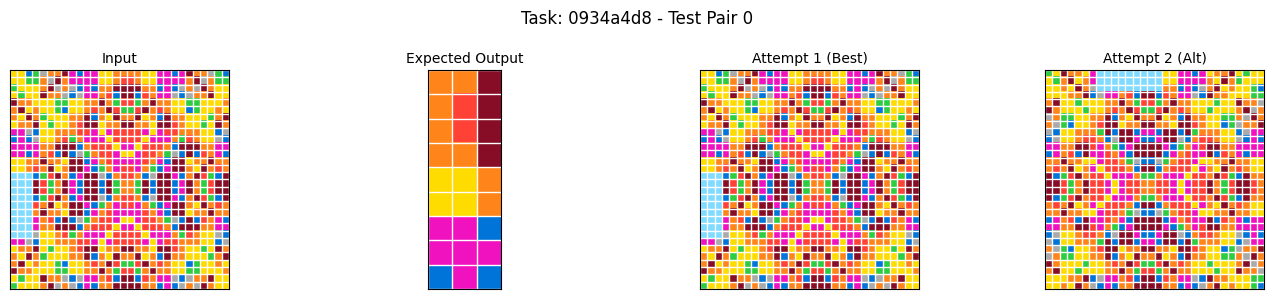

------------------------------------------------------------
Evaluating Task: 135a2760
Training Score: 0.9826 | Solved in 0.51s


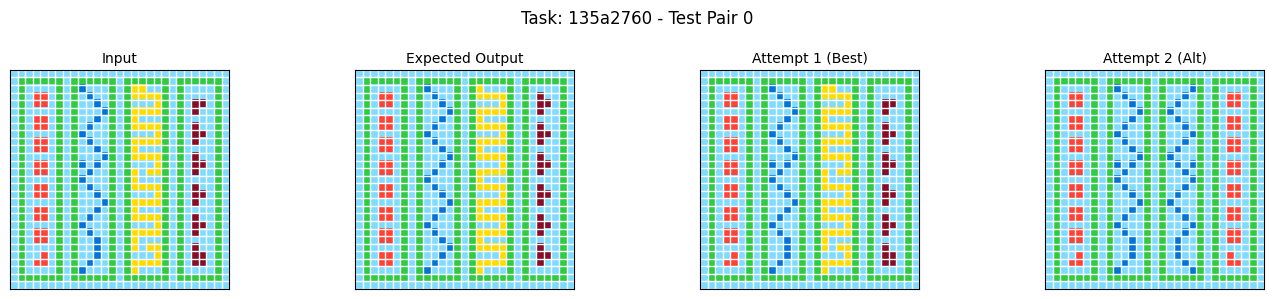

------------------------------------------------------------
Evaluating Task: 136b0064
Training Score: 0.8022 | Solved in 0.11s


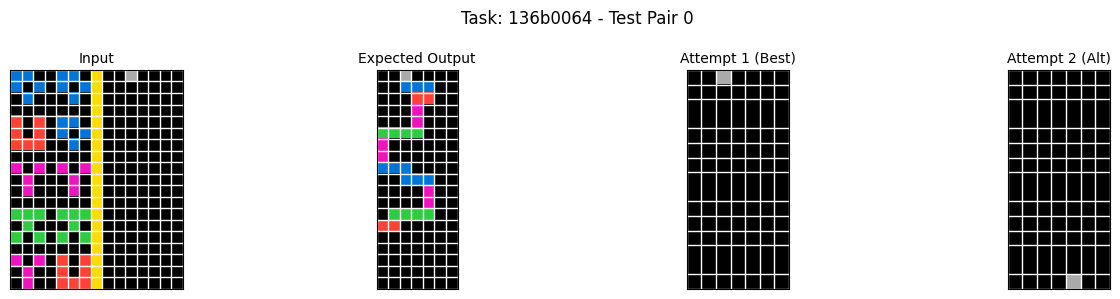

In [56]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import json
import time
import os

# ARC Color Mapping
ARC_COLORS = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'
]
cmap = ListedColormap(ARC_COLORS)


def plot_grid(ax, grid_data, title):
    if hasattr(grid_data, 'data'):
        grid_data = grid_data.data
    grid_data = np.array(grid_data)
    ax.imshow(grid_data, cmap=cmap, vmin=0, vmax=9)
    ax.set_title(title, fontsize=10, pad=5)
    h, w = grid_data.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

def visualize_prediction(task_id, test_idx, inp, expected, pred1, pred2):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    fig.suptitle(f"Task: {task_id} - Test Pair {test_idx}", fontsize=12)
    
    plot_grid(axes[0], inp, "Input")
    if expected is not None:
        plot_grid(axes[1], expected, "Expected Output")
    else:
        axes[1].text(0.5, 0.5, 'Hidden', ha='center', va='center')
        axes[1].axis('off')
        
    plot_grid(axes[2], pred1, "Attempt 1 (Best)")
    plot_grid(axes[3], pred2, "Attempt 2 (Alt)")
    
    plt.tight_layout()
    plt.show()

# Helper to load Kaggle data or use fallback
def first_existing_path(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    return None


def run_eda():
    eval_path = first_existing_path([
        '/kaggle/input/arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json',
        'arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json',
    ])
    sol_path = first_existing_path([
        '/kaggle/input/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json',
        'arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json',
    ])
    
    tasks = {}
    solutions = {}
    
    if eval_path:
        print(f"Loading tasks from {eval_path}")
        with open(eval_path, 'r') as f:
            tasks = json.load(f)
        if sol_path:
            with open(sol_path, 'r') as f:
                solutions = json.load(f)
    else:
        print("Dataset not found. Using a fallback synthetic task for EDA.")
        tasks = {
            "synthetic_task_1": {
                "train": [
                    {"input": [[1,1,0],[0,1,0],[0,0,0]], "output": [[2,2,0],[0,2,0],[0,0,0]]},
                    {"input": [[0,3,3],[0,3,0],[0,0,0]], "output": [[0,2,2],[0,2,0],[0,0,0]]}
                ],
                "test": [{"input": [[0,0,0],[4,4,0],[4,0,0]]}]
            }
        }
        solutions = {
            "synthetic_task_1": [[[0,0,0],[2,2,0],[2,0,0]]]
        }

    # Run solver on first 3 tasks
    task_ids = list(tasks.keys())[:3]
    
    for tid in task_ids:
        print("-" * 60)
        print(f"Evaluating Task: {tid}")
        task = tasks[tid]
        
        t0 = time.time()
        # Fast config for EDA
        preds, score = hybrid_solve(task, ALL_SOLVERS, beam_width=5, population_size=40, max_generations=10)
        elapsed = time.time() - t0
        
        print(f"Training Score: {score:.4f} | Solved in {elapsed:.2f}s")
        
        # Visualize test pairs
        for i, test_pair in enumerate(task['test']):
            inp = test_pair['input']
            expected = solutions.get(tid, [])[i] if tid in solutions and i < len(solutions[tid]) else None
            
            p1 = preds[i]['attempt_1']
            p2 = preds[i]['attempt_2']
            
            visualize_prediction(tid, i, inp, expected, p1, p2)

# Run EDA
run_eda()


## Submission Generation

This final cell solves every task in the ARC-AGI-2 test challenges file and writes a Kaggle-compatible `submission.json` with exactly two attempts per test input.


In [57]:

import json
import os
import time


def load_test_challenges():
    candidates = [
        '/kaggle/input/arc-prize-2026-arc-agi-2/arc-agi_test_challenges.json',
        'arc-prize-2026-arc-agi-2/arc-agi_test_challenges.json',
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f"Loading test challenges from {path}")
            with open(path, 'r') as f:
                return json.load(f)
    raise FileNotFoundError("Could not find arc-agi_test_challenges.json")


def zero_like_input(test_pair):
    inp = test_pair['input']
    h = len(inp)
    w = len(inp[0]) if h else 1
    return [[0 for _ in range(w)] for _ in range(max(h, 1))]


def validate_submission(submission, challenges):
    missing = set(challenges) - set(submission)
    extra = set(submission) - set(challenges)
    if missing or extra:
        raise ValueError(f"Task id mismatch: missing={len(missing)}, extra={len(extra)}")

    for task_id, task in challenges.items():
        preds = submission[task_id]
        if not isinstance(preds, list) or len(preds) != len(task['test']):
            raise ValueError(f"{task_id}: expected {len(task['test'])} prediction entries")
        for idx, pred in enumerate(preds):
            if set(pred.keys()) != {'attempt_1', 'attempt_2'}:
                raise ValueError(f"{task_id}[{idx}]: must contain attempt_1 and attempt_2 only")
            for key in ('attempt_1', 'attempt_2'):
                grid = pred[key]
                if not isinstance(grid, list) or not grid or not all(isinstance(row, list) for row in grid):
                    raise ValueError(f"{task_id}[{idx}].{key}: prediction must be a non-empty 2D list")
                width = len(grid[0])
                if width == 0 or any(len(row) != width for row in grid):
                    raise ValueError(f"{task_id}[{idx}].{key}: rows must be rectangular")
                for row in grid:
                    for value in row:
                        if not isinstance(value, int) or value < 0 or value > 9:
                            raise ValueError(f"{task_id}[{idx}].{key}: values must be integers 0..9")


def build_submission(output_file='submission.json',
                     beam_width=8,
                     population_size=48,
                     max_generations=12):
    challenges = load_test_challenges()
    submission = {}
    started = time.time()

    for index, (task_id, task) in enumerate(challenges.items(), start=1):
        task_start = time.time()
        try:
            preds, score = hybrid_solve(
                task,
                ALL_SOLVERS,
                beam_width=beam_width,
                population_size=population_size,
                max_generations=max_generations,
                ga_verbose=False,
            )
        except Exception as exc:
            print(f"{index:03d}/{len(challenges)} {task_id}: solver error, using zero fallback: {exc}")
            preds = []
            for test_pair in task['test']:
                fallback = zero_like_input(test_pair)
                preds.append({'attempt_1': fallback, 'attempt_2': fallback})
            score = 0.0

        submission[task_id] = preds
        print(f"{index:03d}/{len(challenges)} {task_id}: train_score={score:.4f}, elapsed={time.time() - task_start:.2f}s")

    validate_submission(submission, challenges)
    with open(output_file, 'w') as f:
        json.dump(submission, f)

    print(f"Saved {output_file} with {len(submission)} tasks in {time.time() - started:.1f}s")
    return submission


submission = build_submission()


Loading test challenges from arc-prize-2026-arc-agi-2/arc-agi_test_challenges.json
001/240 00576224: train_score=0.6667, elapsed=0.18s
002/240 007bbfb7: train_score=0.8222, elapsed=0.67s
003/240 009d5c81: train_score=0.9378, elapsed=0.86s
004/240 00d62c1b: train_score=1.0000, elapsed=0.02s
005/240 00dbd492: train_score=0.8289, elapsed=0.66s
006/240 017c7c7b: train_score=0.0000, elapsed=0.09s
007/240 025d127b: train_score=0.8532, elapsed=0.27s
008/240 03560426: train_score=0.8167, elapsed=0.50s
009/240 045e512c: train_score=0.9305, elapsed=0.78s
010/240 0520fde7: train_score=0.5185, elapsed=0.16s
011/240 05269061: train_score=0.4558, elapsed=0.39s
012/240 05a7bcf2: train_score=0.7430, elapsed=1.47s
013/240 05f2a901: train_score=0.9205, elapsed=0.49s
014/240 0607ce86: train_score=0.9072, elapsed=1.10s
015/240 0692e18c: train_score=0.7942, elapsed=0.46s
016/240 06df4c85: train_score=0.9380, elapsed=1.35s
017/240 070dd51e: train_score=0.9267, elapsed=0.59s
018/240 08ed6ac7: train_score=0.8